In [1]:
"""
================================================================================
Machine Learning Analysis of CXCR1 and CXCR2 Assay Modalities

Pipeline: Data Curation, Scaffold-Split Validation, Statistical Profiling,
          and Visualization
================================================================================
"""

import os
import sys

# =====================================================================
# INSTALLATIONS & IMPORTS
# =====================================================================
try:
    import chembl_webresource_client
    import rdkit
    import imblearn
    import sklearn
    import cairosvg
except ImportError:
    os.system('pip install chembl_webresource_client rdkit imbalanced-learn scikit-learn cairosvg -q')
    import chembl_webresource_client
    import rdkit
    import imblearn
    import sklearn
    import cairosvg

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns
import joblib

from chembl_webresource_client.new_client import new_client
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, AllChem, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.MolStandardize import rdMolStandardize

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.model_selection import GroupShuffleSplit, permutation_test_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.utils import resample
from sklearn.dummy import DummyClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline ###
from IPython.display import display, Markdown, HTML

# Check versions
!python --version
print(f"CHEMBL version: {chembl_webresource_client.__version__}")
print(f"RDKit version: {rdkit.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Imbalanced-learn version: {imblearn.__version__}")
print(f"Pandas version: {pd.__version__}")

RDLogger.DisableLog('rdApp.*')

/usr/local/lib/python3.13/dist-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


Python 3.13.15
CHEMBL version: 0.10.9
RDKit version: 2026.03.6
Scikit-learn version: 1.6.1
Imbalanced-learn version: 0.14.2
Pandas version: 2.2.3


In [2]:
# Download and install Arial font for strict journal formatting compliance
!wget -q https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf
!mkdir -p /usr/share/fonts/truetype/custom
!mv Arial.ttf /usr/share/fonts/truetype/custom/
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/custom/Arial.ttf')

In [3]:
# =====================================================================
# CONFIGURATIONS
# =====================================================================
TARGETS = {'CXCR1': 'CHEMBL4029', 'CXCR2': 'CHEMBL2434'}
BINDING_KEYWORDS = 'binding|displacement|125I|radioligand|SPA|DELFIA|AF647'
FUNCTIONAL_KEYWORDS = 'beta-arrestin|recruitment|PathHunter|Tango|calcium|calicum|reporter gene|myeloperoxidase|FLIPR|CD11b|chemotaxis'
EXCLUDE_KEYWORDS = 'unknown origin'

# Set to True to query the live ChEMBL API.
# Set to False to load the published dataset (required to reproduce manuscript results).
FETCH_CHEMBL_NEW = False

In [5]:
# =====================================================================
# 1. Programmatic retrieval of bioactivity data (IC50) from ChEMBL
# =====================================================================
if FETCH_CHEMBL_NEW:
    print("--- 1. Data Retrieval ---")
    print("FETCH_CHEMBL_NEW is True: Querying live ChEMBL API...")
    activity = new_client.activity
    all_data = []

    for name, chembl_id in TARGETS.items():
        res = activity.filter(target_chembl_id=chembl_id, standard_type="IC50")
        df = pd.DataFrame.from_dict(res)
        if not df.empty:
            df['Receptor'] = name
            all_data.append(df)

    master_df = pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()
    master_df = master_df[['molecule_chembl_id', 'canonical_smiles', 'pchembl_value',
                           'assay_description', 'Receptor', 'assay_chembl_id', 'document_chembl_id']].copy()

    master_df.dropna(subset=['canonical_smiles', 'pchembl_value', 'assay_description'], inplace=True)
    master_df['pchembl_value'] = pd.to_numeric(master_df['pchembl_value'], errors='coerce')
    master_df.dropna(subset=['pchembl_value'], inplace=True)

    # Save the newly fetched data
    master_df.to_csv('01_raw_chembl_data.csv', index=False)
    print(f"Total usable raw records fetched and saved: {len(master_df)}")

else:
    print("FETCH_CHEMBL_NEW is False: Loading dataset to reproduce the result...")
    try:
        master_df = pd.read_csv('01_raw_chembl_data.csv')
        print(f"Successfully loaded {len(master_df)} raw records.")
    except FileNotFoundError:
        print("Error: '01_raw_chembl_data.csv' not found. Please set FETCH_LIVE_DATA = True to download it.")

# =====================================================================
# 2. Standardize Molecules
# =====================================================================
print("\n--- 2. Standardizing Molecules (Stripping salts, neutralizing) ---")
def standardize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if not mol: return None
        mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
        mol = rdMolStandardize.Uncharger().uncharge(mol)
        mol = rdMolStandardize.TautomerEnumerator().Canonicalize(mol)
        return Chem.MolToSmiles(mol)
    except:
        return None

master_df['standardized_smiles'] = master_df['canonical_smiles'].apply(standardize_smiles)
master_df.dropna(subset=['standardized_smiles'], inplace=True)

master_df.to_csv('02_standardized_chembl_data.csv', index=False)
print(f"Standardized records saved to '02_standardized_chembl_data.csv': {len(master_df)}")

# =====================================================================
# 3. Data curation and stratification into binding vs. functional
# =====================================================================
print("\n--- 3. Curation & Stratification ---")
def extract_modality(df, keyword_pattern, is_binding=False):
    # 1. Base exclusion (Remove 'unknown origin', etc.)
    valid = df[~df['assay_description'].str.contains(EXCLUDE_KEYWORDS, case=False, na=False)]

    # 2. STRICT ANTI-LEAKAGE RULE: Actively ban functional words from Binding
    if is_binding:
        valid = valid[~valid['assay_description'].str.contains(FUNCTIONAL_KEYWORDS, case=False, na=False)]

    # 3. Positive match
    modality = valid[valid['assay_description'].str.contains(keyword_pattern, case=False, na=False)].copy()

    # 4. Aggregate duplicates
    modality = modality.groupby('standardized_smiles', as_index=False).agg({
        'pchembl_value': 'median',
        'molecule_chembl_id': 'first',
        'assay_chembl_id': lambda x: '; '.join(set(x.dropna().astype(str))),
        'document_chembl_id': lambda x: '; '.join(set(x.dropna().astype(str))),
        'assay_description': lambda x: '; '.join(set(x.dropna().astype(str)))
    })
    return modality

cxcr1 = master_df[master_df['Receptor'] == 'CXCR1']
cxcr2 = master_df[master_df['Receptor'] == 'CXCR2']

# =====================================================================
# 4. Calculation of receptor selectivity profiles (CXCR2 vs. CXCR1)
# =====================================================================
print("\n--- 4. Selectivity Calculation ---")
p_bind = pd.merge(extract_modality(cxcr1, BINDING_KEYWORDS, is_binding=True),
                  extract_modality(cxcr2, BINDING_KEYWORDS, is_binding=True),
                  on='standardized_smiles', suffixes=('_cxcr1', '_cxcr2'))

p_func = pd.merge(extract_modality(cxcr1, FUNCTIONAL_KEYWORDS, is_binding=False),
                  extract_modality(cxcr2, FUNCTIONAL_KEYWORDS, is_binding=False),
                  on='standardized_smiles', suffixes=('_cxcr1', '_cxcr2'))

# Calculate the selectivity score
for d in [p_bind, p_func]:
    d['Selectivity_Score'] = d['pchembl_value_cxcr2'] - d['pchembl_value_cxcr1']

print(f"Final Paired Binding Compounds: {len(p_bind)}")
print(f"Final Paired Functional Compounds: {len(p_func)}")

# ---------------------------------------------------------------------
# 4.1 Functional Assay Distribution Analysis
# ---------------------------------------------------------------------
print("\n--- 4.1 Functional Assay Modality Distribution ---")
func_descriptions = p_func['assay_description_cxcr2'].str.lower().fillna('')

assay_categories = {
    'Calcium/FLIPR': 'calcium|calicum|flipr',
    'beta-Arrestin (PathHunter/Tango)': 'beta-arrestin|pathhunter|tango',
    'Chemotaxis / Cell Migration': 'chemotaxis',
    'Reporter Gene': 'reporter gene',
    'CD11b / Myeloperoxidase': 'cd11b|myeloperoxidase'
}

print(f"{'Assay Category':<35} | {'Count':>5} | {'Percentage':>10}")
print("-" * 57)

total_func_records = len(p_func)
for category_name, regex_pattern in assay_categories.items():
    match_count = func_descriptions.str.contains(regex_pattern).sum()
    percentage = (match_count / total_func_records) * 100 if total_func_records > 0 else 0
    print(f"{category_name:<35} | {match_count:>5} | {percentage:>9.1f}%")

# ---------------------------------------------------------------------
# 4.2 Export Curated Cohorts
# ---------------------------------------------------------------------
p_bind.to_csv('03_paired_binding_curated.csv', index=False)
p_func.to_csv('04_paired_functional_curated.csv', index=False)
print("\n--- 4.2 Cohort Export ---")
print("Paired binding cohort saved to '03_paired_binding_curated.csv'")
print("Paired functional cohort saved to '04_paired_functional_curated.csv'")




FETCH_CHEMBL_NEW is False: Loading dataset to reproduce the result...
Successfully loaded 1421 raw records.

--- 2. Standardizing Molecules (Stripping salts, neutralizing) ---
Standardized records saved to '02_standardized_chembl_data.csv': 1421

--- 3. Curation & Stratification ---

--- 4. Selectivity Calculation ---
Final Paired Binding Compounds: 55
Final Paired Functional Compounds: 69

--- 4.1 Functional Assay Modality Distribution ---
Assay Category                      | Count | Percentage
---------------------------------------------------------
Calcium/FLIPR                       |     1 |       1.4%
beta-Arrestin (PathHunter/Tango)    |    65 |      94.2%
Chemotaxis / Cell Migration         |     1 |       1.4%
Reporter Gene                       |     0 |       0.0%
CD11b / Myeloperoxidase             |     2 |       2.9%

--- 4.2 Cohort Export ---
Paired binding cohort saved to '03_paired_binding_curated.csv'
Paired functional cohort saved to '04_paired_functional_curated.c

In [6]:
# =====================================================================
# 5. Bemis-Murcko scaffold extraction for chemotype analysis
# =====================================================================
print("\n--- 5. Scaffold Extraction ---")
def get_bm(s):
    try:
        mol = Chem.MolFromSmiles(s)
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except:
        return None

# Apply scaffold extraction to both cohorts
for df_temp in [p_bind, p_func]:
    df_temp['BM_Scaffold_SMILES'] = df_temp['standardized_smiles'].apply(get_bm)

# Temporarily combine to profile the dataset's chemical diversity
temp_combined = pd.concat([p_bind, p_func], ignore_index=True)
total_molecules = len(temp_combined)
unique_scaffolds = temp_combined['BM_Scaffold_SMILES'].nunique()

print(f"Total curated molecules: {total_molecules}")
print(f"Total unique Bemis-Murcko scaffolds: {unique_scaffolds}")
print("\nTop 5 Most Frequent Scaffolds (indicating analog series):")
print(temp_combined['BM_Scaffold_SMILES'].value_counts().head(5))

# =====================================================================
# 6. Physicochemical feature extraction and Random Forest classification
# =====================================================================
print("\n--- 6. Feature Extraction & ML Profiling (Scaffold-Split) ---")

def get_feats(s):
    m = Chem.MolFromSmiles(s)
    if m is None:
        return pd.Series(dtype=float)
    return pd.Series({
        'MolWt': Descriptors.MolWt(m),
        'LogP': Descriptors.MolLogP(m),
        'TPSA': Descriptors.TPSA(m),
        'HBD': Descriptors.NumHDonors(m),
        'HBA': Descriptors.NumHAcceptors(m),
        'Fsp3': Descriptors.FractionCSP3(m)
    })

p_bind['Label'] = 0
p_func['Label'] = 1

combined = pd.concat([p_bind, p_func], ignore_index=True)
combined['Modality'] = combined['Label'].map({0: 'Binding Cohort', 1: 'Functional Cohort'})

print("Calculating properties for Combined Dataset...")
feats = combined['standardized_smiles'].apply(get_feats)
combined = pd.concat([combined, feats], axis=1)
combined.dropna(subset=['MolWt', 'BM_Scaffold_SMILES'], inplace=True)

X = combined[['MolWt', 'LogP', 'TPSA', 'HBD', 'HBA', 'Fsp3']]
y = combined['Label']
groups = combined['BM_Scaffold_SMILES']

# Implement Scaffold-Split to prevent analog data leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

combined['Validation_Group'] = 'Train'
combined.iloc[test_idx, combined.columns.get_loc('Validation_Group')] = 'Test'

combined.to_csv('05_master_compound_table_final.csv', index=False)
print(f"Master table saved to '05_master_compound_table_final.csv': {len(combined)} records")

# ---------------------------------------------------------------------
# Train Primary Random Forest Model
# ---------------------------------------------------------------------
print("\n--- Training Random Forest (Scaffold-Split & Balanced Weights) ---")
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("\n=== FINAL MODEL PERFORMANCE ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

test_roc_auc = roc_auc_score(y_test, y_prob)
print(f"Test Set ROC-AUC: {test_roc_auc:.3f}")

# ---------------------------------------------------------------------
# 6.1 Baseline Model Evaluation
# ---------------------------------------------------------------------
print("\n--- 6.1 Baseline Model Comparison ---")
dummy_clf = DummyClassifier(strategy='prior')
dummy_clf.fit(X_train, y_train)
dummy_prob = dummy_clf.predict_proba(X_test)[:, 1]
dummy_auc = roc_auc_score(y_test, dummy_prob)

print(f"Dummy Classifier (Prior) ROC-AUC : {dummy_auc:.3f}")
print(f"Random Forest Classifier ROC-AUC : {test_roc_auc:.3f}")

# ---------------------------------------------------------------------
# 6.2 Evaluation of Class Balancing Strategies
# ---------------------------------------------------------------------
print("\n--- 6.2 Class Balancing Strategy Comparison ---")

rf_unweighted = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_unweighted.fit(X_train, y_train)
auc_unweighted = roc_auc_score(y_test, rf_unweighted.predict_proba(X_test)[:, 1])

pipe_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])
pipe_smote.fit(X_train, y_train)
auc_smote = roc_auc_score(y_test, pipe_smote.predict_proba(X_test)[:, 1])

auc_class_weight = test_roc_auc

print(f"{'Strategy':<25} | {'Test ROC-AUC':>12}")
print("-" * 40)
print(f"{'Unweighted (None)':<25} | {auc_unweighted:>12.3f}")
print(f"{'SMOTE Oversampling':<25} | {auc_smote:>12.3f}")
print(f"{'Class Weights (Selected)':<25} | {auc_class_weight:>12.3f}")

# Export Model
joblib.dump(rf_model, '06_final_rf_model.pkl')
print("\n--- Model Export ---")
print("Trained Random Forest model saved to '06_final_rf_model.pkl'")




--- 5. Scaffold Extraction ---
Total curated molecules: 124
Total unique Bemis-Murcko scaffolds: 49

Top 5 Most Frequent Scaffolds (indicating analog series):
BM_Scaffold_SMILES
O=C(Nc1ccccc1)Nc1ccccc1                      14
O=c1c(Nc2ccccc2)c(NC(c2ccco2)C2COC2)c1=O     11
C(=Nc1ccccc1)Nc1ccccc1                       10
O=c1c(Nc2ccccc2)c(NC(c2ccco2)C2CCCS2)c1=O     7
O=c1c(NCc2ccco2)c(Nc2ccccc2)c1=O              7
Name: count, dtype: int64

--- 6. Feature Extraction & ML Profiling (Scaffold-Split) ---
Calculating properties for Combined Dataset...
Master table saved to '05_master_compound_table_final.csv': 124 records

--- Training Random Forest (Scaffold-Split & Balanced Weights) ---

=== FINAL MODEL PERFORMANCE ===
Confusion Matrix:
[[ 6  1]
 [ 0 14]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.93      1.00      0.97        14

    accuracy                           0.95    

In [7]:
# =====================================================================
# 7. Model Statistical Validation & Threshold Testing
# =====================================================================
print("\n--- 7. Statistical Validation ---")

# ---------------------------------------------------------------------
# 7.1 Calculate 95% Confidence Intervals for ROC-AUC (Bootstrapping)
# ---------------------------------------------------------------------
print("\n[7.1] Calculating 95% Confidence Interval for Test ROC-AUC")
n_bootstraps = 1000
bootstrapped_scores = []
y_test_array = y_test.values
y_prob_array = y_prob

rng = np.random.RandomState(42)
for i in range(n_bootstraps):
    indices = rng.randint(0, len(y_prob_array), len(y_prob_array))
    if len(np.unique(y_test_array[indices])) < 2:
        continue
    score = roc_auc_score(y_test_array[indices], y_prob_array[indices])
    bootstrapped_scores.append(score)

ci_lower = np.percentile(bootstrapped_scores, 2.5)
ci_upper = np.percentile(bootstrapped_scores, 97.5)
print(f"Test ROC-AUC: {test_roc_auc:.3f} (95% CI: {ci_lower:.3f} - {ci_upper:.3f})")

# ---------------------------------------------------------------------
# 7.2 Custom Label-Permutation Control (Bypassing sklearn index bug)
# ---------------------------------------------------------------------
print("\n[7.2] Running Label-Permutation Control (1000 permutations)")

n_permutations = 1000
permuted_scores = []
y_train_array = y_train.values
rng = np.random.RandomState(42)

for i in range(n_permutations):
    y_train_shuffled = rng.permutation(y_train_array)
    rf_perm = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
    rf_perm.fit(X_train, y_train_shuffled)

    perm_prob = rf_perm.predict_proba(X_test)[:, 1]
    perm_auc = roc_auc_score(y_test, perm_prob)
    permuted_scores.append(perm_auc)

permuted_scores = np.array(permuted_scores)
mean_perm_auc = permuted_scores.mean()
std_perm_auc = permuted_scores.std()

n_exceeding_observed = np.sum(permuted_scores >= test_roc_auc)
p_value = (n_exceeding_observed + 1) / (n_permutations + 1)

print(f"True Model ROC-AUC: {test_roc_auc:.3f}")
print(f"Mean Random Permuted ROC-AUC: {mean_perm_auc:.3f} +/- {std_perm_auc:.3f}")
print(f"Permutation p-value: {p_value:.4f}")

if p_value < 0.05:
    print("-> Conclusion: Model performance is statistically significant (p < 0.05).")
else:
    print("-> Conclusion: Model performance is not statistically distinguished from chance (p >= 0.05).")

# ---------------------------------------------------------------------
# 7.3 Feature Distribution Analysis on Training Data
# ---------------------------------------------------------------------
print("\n[7.3] Analyzing Fsp3 and HBA Distributions in the Training Set")

train_data = X_train.copy()
train_data['Label'] = y_train.values
train_data['Modality'] = train_data['Label'].map({0: 'Binding Cohort', 1: 'Functional Cohort'})

print("\n--- Fsp3 Summary Statistics ---")
print(train_data.groupby('Modality')['Fsp3'].describe()[['count', 'mean', 'std', '50%', 'min', 'max']].round(3))

print("\n--- HBA Summary Statistics ---")
print(train_data.groupby('Modality')['HBA'].describe()[['count', 'mean', 'std', '50%', 'min', 'max']].round(3))

# ---------------------------------------------------------------------
# 7.4 Validating Original Thresholds on Hold-out Test Set
# ---------------------------------------------------------------------
print("\n[7.4] Validating Proposed Thresholds (Fsp3 > 0.35 and HBA >= 8)")
rule_mask = (X_test['Fsp3'] > 0.35) & (X_test['HBA'] >= 8)

total_predicted = rule_mask.sum()
correct_functional = (rule_mask & (y_test == 1)).sum()
actual_functional_in_test = (y_test == 1).sum()

if total_predicted > 0:
    precision = correct_functional / total_predicted
    recall = correct_functional / actual_functional_in_test
    print(f"Compounds flagged by threshold: {total_predicted} out of {len(X_test)}")
    print(f"Correctly identified as Functional: {correct_functional}")
    print(f"Rule Precision: {precision*100:.1f}%")
    print(f"Rule Recall: {recall*100:.1f}%")
else:
    print("The proposed threshold did not flag any compounds in the test set.")


--- 7. Statistical Validation ---

[7.1] Calculating 95% Confidence Interval for Test ROC-AUC
Test ROC-AUC: 0.980 (95% CI: 0.900 - 1.000)

[7.2] Running Label-Permutation Control (1000 permutations)
True Model ROC-AUC: 0.980
Mean Random Permuted ROC-AUC: 0.491 +/- 0.186
Permutation p-value: 0.0030
-> Conclusion: Model performance is statistically significant (p < 0.05).

[7.3] Analyzing Fsp3 and HBA Distributions in the Training Set

--- Fsp3 Summary Statistics ---
                   count   mean    std    50%    min    max
Modality                                                   
Binding Cohort      48.0  0.181  0.152  0.176  0.000  0.500
Functional Cohort   55.0  0.364  0.059  0.375  0.053  0.467

--- HBA Summary Statistics ---
                   count   mean    std  50%  min   max
Modality                                              
Binding Cohort      48.0  5.333  1.629  5.0  2.0   8.0
Functional Cohort   55.0  8.255  0.886  8.0  5.0  10.0

[7.4] Validating Proposed Thresholds


--- 8. Generating Publication-Ready Figures and Tables ---
Generating Figure 1: Selectivity Distribution...


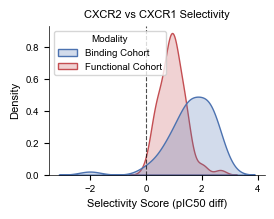

Generating Figure 2: Representative Scaffolds...


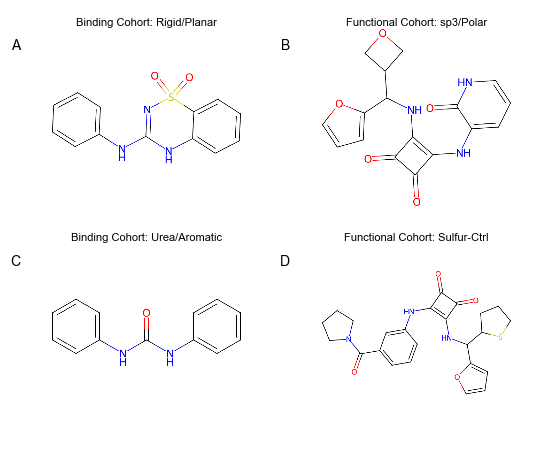

Generating Figure 3: Physicochemical Properties...


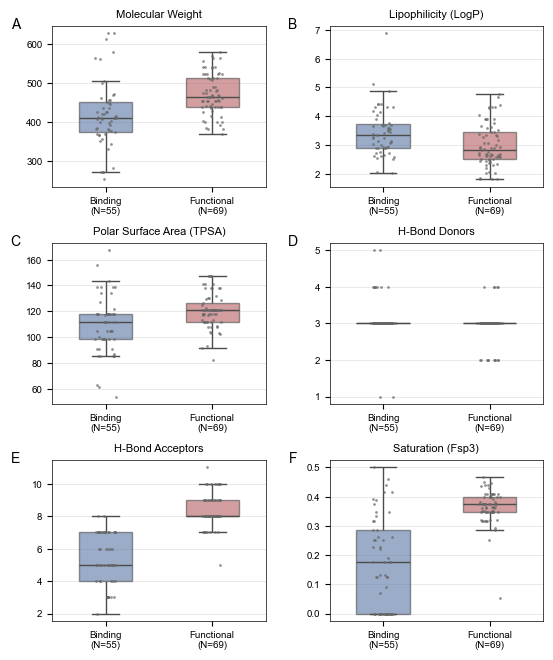

Generating Figure 4: Feature Importance...

Generating Tables 1 and 2...


,Assay Category,Count,Percentage (%)
0,Calcium/FLIPR,1,1.4
1,beta-Arrestin (PathHunter/Tango),65,94.2
2,Chemotaxis / Cell Migration,1,1.4
3,Reporter Gene,0,0.0
4,CD11b / Myeloperoxidase,2,2.9


,Strategy,Test ROC-AUC
0,Unweighted (None),0.969
1,SMOTE Oversampling,0.969
2,Class Weights (Selected),0.980



--- Generating Table 3 ---


,Property,Binding (N=55),Functional (N=69),Cohen's d (Effect Size)
0,MolWt,418.93 ± 83.13,471.50 ± 51.29,0.78
1,LogP,3.45 ± 0.82,3.00 ± 0.73,-0.57
2,TPSA,109.33 ± 21.80,120.81 ± 13.16,0.66
3,HBD,3.13 ± 0.64,2.93 ± 0.46,-0.36
4,HBA,5.38 ± 1.56,8.33 ± 0.98,2.33
5,Fsp3,0.17 ± 0.16,0.37 ± 0.06,1.75



Generating Tables S1 & S2...


,BM_Scaffold_SMILES,N,Mean Selectivity,Std Dev
7,O=S1(=O)N=C(Nc2ccccc2)Nc2ccccc21,5,2.25,0.13
3,O=C(Nc1ccccc1)Nc1ccccc1,14,2.02,0.81
10,O=c1c(NCc2ccccc2)c(Nc2ccccc2)c1=O,3,1.81,0.39
0,C(=Nc1ccccc1)Nc1ccccc1,10,1.61,0.42
6,O=S(=O)(NCN1CCOCC1)c1cccc(N=CNc2ccccc2)c1,4,1.52,0.26
11,O=c1c(NCc2ccco2)c(Nc2ccccc2)c1=O,6,1.08,0.64


,BM_Scaffold_SMILES,N,Mean Selectivity,Std Dev
11,O=c1[nH]cccc1Nc1c(NC(c2ccco2)C2COC2)c(=O)c1=O,4,1.10,0.14
22,O=c1c(Nc2ccccc2)c(NC(c2ccco2)C2COC2)c1=O,11,1.09,0.42
1,O=C(c1cccc(Nc2c(NC(c3ccco3)C3CCCS3)c(=O)c2=O)c...,4,0.94,0.29
2,O=C(c1cccc(Nc2c(NC(c3ccco3)C3COC3)c(=O)c2=O)c1...,6,0.85,0.33
28,O=c1c(Nc2ccccc2)c(N[C@@H](c2ccco2)C2COC2)c1=O,4,0.82,0.41
19,O=c1c(Nc2ccccc2)c(NC(c2ccco2)C2CCCS2)c1=O,7,0.45,0.31


Tables S1 and S2 saved.


In [8]:
# =====================================================================
# 8. Generating Visualizations, Tables, and TOC
# =====================================================================
print("\n--- 8. Generating Publication-Ready Figures and Tables ---")

# Define palette locally
CUSTOM_PALETTE = {'Binding Cohort': '#4C72B0', 'Functional Cohort': '#C44E52'}

# ---------------------------------------------------------------------
# 8.0 Apply Formatting Rules Globally
# ---------------------------------------------------------------------
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 7
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['axes.labelsize'] = 8
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['legend.fontsize'] = 7

CM_TO_INCH = 1 / 2.54
WIDTH_DOUBLE = 14 * CM_TO_INCH  # 14 cm double column
WIDTH_SINGLE = 7 * CM_TO_INCH   # 7 cm single column

# ---------------------------------------------------------------------
# 8.1 FIGURE 1: Selectivity Distribution
# ---------------------------------------------------------------------
print("Generating Figure 1: Selectivity Distribution...")

fig1, ax1 = plt.subplots(figsize=(WIDTH_SINGLE, WIDTH_SINGLE * 0.8))

sns.kdeplot(data=combined, x='Selectivity_Score', hue='Modality', fill=True,
            common_norm=False, palette=CUSTOM_PALETTE, ax=ax1, linewidth=1)
ax1.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

ax1.set_title('CXCR2 vs CXCR1 Selectivity', fontsize=8)
ax1.set_xlabel('Selectivity Score (pIC50 diff)')
ax1.set_ylabel('Density')
sns.despine()

plt.tight_layout()
fig1.savefig('Figure_1_Selectivity_Distribution.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.show()
plt.close(fig1)

# ---------------------------------------------------------------------
# 8.2 FIGURE 2: Representative Scaffolds
# ---------------------------------------------------------------------
print("Generating Figure 2: Representative Scaffolds...")

bind_stats = p_bind.groupby('BM_Scaffold_SMILES')['Selectivity_Score'].agg(['count', 'mean']).reset_index()
bind_scaffolds = bind_stats[bind_stats['count'] >= 3].sort_values('mean', ascending=False)['BM_Scaffold_SMILES'].tolist()

func_stats = p_func.groupby('BM_Scaffold_SMILES')['Selectivity_Score'].agg(['count', 'mean']).reset_index()
func_scaffolds = func_stats[func_stats['count'] >= 3].sort_values('mean', ascending=False)['BM_Scaffold_SMILES'].tolist()

s_bind_1 = bind_scaffolds[0] if len(bind_scaffolds) > 0 else ""
s_func_1 = func_scaffolds[0] if len(func_scaffolds) > 0 else ""
s_bind_2 = bind_scaffolds[1] if len(bind_scaffolds) > 1 else ""
sulfur_scaffold = next((s for s in func_scaffolds if 'S' in s), func_scaffolds[1] if len(func_scaffolds) > 1 else "")

grid_smiles = [s_bind_1, s_func_1, s_bind_2, sulfur_scaffold]
grid_titles = ['Binding Cohort: Rigid/Planar', 'Functional Cohort: sp3/Polar', 'Binding Cohort: Urea/Aromatic', 'Functional Cohort: Sulfur-Ctrl']

fig2, axes2 = plt.subplots(2, 2, figsize=(WIDTH_DOUBLE, WIDTH_DOUBLE * 0.8))
axes2_flat = axes2.flatten()
panel_labels_2 = ['A', 'B', 'C', 'D']

for i, (smiles, title, label) in enumerate(zip(grid_smiles, grid_titles, panel_labels_2)):
    ax = axes2_flat[i]
    ax.axis('off')
    if smiles:
        mol = Chem.MolFromSmiles(smiles)
        img = Draw.MolToImage(mol, size=(600, 600))
        imagebox = OffsetImage(img, zoom=0.25)
        ab = AnnotationBbox(imagebox, (0.5, 0.5), frameon=False)
        ax.add_artist(ab)
        ax.set_title(title, fontsize=8, pad=15)
    ax.text(-0.05, 1.05, label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='right')

plt.tight_layout()
fig2.savefig('Figure_2_Representative_scaffolds.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.show()
plt.close(fig2)

# ---------------------------------------------------------------------
# 8.3 FIGURE 3: Physicochemical Property Distributions
# ---------------------------------------------------------------------
print("Generating Figure 3: Physicochemical Properties...")


narrative_metrics = [
    ('MolWt', 'Molecular Weight'), ('LogP', 'Lipophilicity (LogP)'),
    ('TPSA', 'Polar Surface Area (TPSA)'), ('HBD', 'H-Bond Donors'),
    ('HBA', 'H-Bond Acceptors'), ('Fsp3', 'Saturation (Fsp3)')
]

fig3, axes3 = plt.subplots(3, 2, figsize=(WIDTH_DOUBLE, WIDTH_DOUBLE * 1.2))
axes3_flat = axes3.flatten()
panel_labels_3 = ['A', 'B', 'C', 'D', 'E', 'F']

for i, ((col, title_text), label) in enumerate(zip(narrative_metrics, panel_labels_3)):
    ax = axes3_flat[i]

    sns.boxplot(data=combined, x='Modality', y=col, hue='Modality', ax=ax, palette=CUSTOM_PALETTE,
                width=0.5, fliersize=0, boxprops=dict(alpha=0.6), legend=False)
    sns.stripplot(data=combined, x='Modality', y=col, ax=ax, color='#666666', size=2, alpha=0.7, jitter=True)

    ax.set_title(title_text, fontsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([0, 1])

    n_bind_fig = len(combined[combined['Label'] == 0])
    n_func_fig = len(combined[combined['Label'] == 1])
    ax.set_xticklabels([f'Binding\n(N={n_bind_fig})', f'Functional\n(N={n_func_fig})'])

    ax.yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)
    ax.text(-0.15, 1.05, label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.35)
fig3.savefig('Figure_3_Physicochemical_distributions.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.show()
plt.close(fig3)

# ---------------------------------------------------------------------
# 8.4 FIGURE 4: Feature Importance Analysis (With Uncertainty)
# ---------------------------------------------------------------------
print("Generating Figure 4: Feature Importance...")

importances = rf_model.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances,
    'Std': std
}).sort_values('Importance', ascending=True)

fig4, ax4 = plt.subplots(figsize=(WIDTH_SINGLE, WIDTH_SINGLE * 0.8))

ax4.barh(fi_df['Feature'], fi_df['Importance'], xerr=fi_df['Std'],
         capsize=2, color='#8EB897', edgecolor='#666666', linewidth=0.35)

ax4.set_title("Random Forest Feature Importance", fontsize=8)
ax4.set_xlabel("Mean Decrease in Impurity")
ax4.xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.7)
ax4.set_axisbelow(True)

plt.tight_layout()
fig4.savefig('Figure_4_Feature_importance.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.close(fig4)

# ---------------------------------------------------------------------
# 8.5 TABLE 1 & 2: Assay Distribution and Balancing Strategies
# ---------------------------------------------------------------------
print("\nGenerating Tables 1 and 2...")
from IPython.display import display
# --- Table 1: Functional Assay Modality Distribution ---
table1_rows = []
for category_name, regex_pattern in assay_categories.items():
    match_count = func_descriptions.str.contains(regex_pattern).sum()
    percentage = (match_count / total_func_records) * 100 if total_func_records > 0 else 0
    table1_rows.append({
        'Assay Category': category_name,
        'Count': match_count,
        'Percentage (%)': round(percentage, 1)
    })

table1_df = pd.DataFrame(table1_rows)
table1_df.to_csv('Table_1_Functional_Assay_Distribution.csv', index=False)
display(table1_df)

# --- Table 2: Class Balancing Strategy Comparison ---
table2_df = pd.DataFrame([
    {'Strategy': 'Unweighted (None)', 'Test ROC-AUC': round(auc_unweighted, 3)},
    {'Strategy': 'SMOTE Oversampling', 'Test ROC-AUC': round(auc_smote, 3)},
    {'Strategy': 'Class Weights (Selected)', 'Test ROC-AUC': round(auc_class_weight, 3)}
])
table2_df.to_csv('Table_2_Balancing_Strategies.csv', index=False)
display(table2_df)

# ---------------------------------------------------------------------
# 8.6 TABLE 3: Mean Physicochemical Properties (With Effect Sizes)
# ---------------------------------------------------------------------
print("\n--- Generating Table 3 ---")

feat_cols = [c[0] for c in narrative_metrics]
g_bind = combined[combined['Label'] == 0][feat_cols]
g_func = combined[combined['Label'] == 1][feat_cols]

n_bind, n_func = len(g_bind), len(g_func)
table3_rows = []

for col in feat_cols:
    m_b, s_b = g_bind[col].mean(), g_bind[col].std()
    m_f, s_f = g_func[col].mean(), g_func[col].std()
    pooled_std = np.sqrt(((n_bind - 1) * (s_b ** 2) + (n_func - 1) * (s_f ** 2)) / (n_bind + n_func - 2))
    cohens_d = (m_f - m_b) / pooled_std if pooled_std > 0 else 0

    table3_rows.append({
        'Property': col,
        f'Binding (N={n_bind})': f"{m_b:.2f} \u00b1 {s_b:.2f}",
        f'Functional (N={n_func})': f"{m_f:.2f} \u00b1 {s_f:.2f}",
        "Cohen's d (Effect Size)": f"{cohens_d:.2f}"
    })

table3_df = pd.DataFrame(table3_rows)
table3_df.to_csv('Table_3_Physicochemical_Props.csv', index=False)
display(table3_df)

# ---------------------------------------------------------------------
# 8.6 TABLES S1 & S2: Scaffolds
# ---------------------------------------------------------------------
print("\nGenerating Tables S1 & S2...")
table_s1 = p_bind.groupby('BM_Scaffold_SMILES')['Selectivity_Score'].agg(['count', 'mean', 'std']).reset_index()
table_s1 = table_s1[table_s1['count'] >= 3].sort_values('mean', ascending=False).round(2)
table_s1.rename(columns={'count': 'N', 'mean': 'Mean Selectivity', 'std': 'Std Dev'}, inplace=True)
table_s1.to_csv('Table_S1_Binding_Scaffolds.csv', index=False)
display(table_s1)

table_s2 = p_func.groupby('BM_Scaffold_SMILES')['Selectivity_Score'].agg(['count', 'mean', 'std']).reset_index()
table_s2 = table_s2[table_s2['count'] >= 3].sort_values('mean', ascending=False).round(2)
table_s2.rename(columns={'count': 'N', 'mean': 'Mean Selectivity', 'std': 'Std Dev'}, inplace=True)
table_s2.to_csv('Table_S2_Functional_Scaffolds.csv', index=False)
display(table_s2)
print("Tables S1 and S2 saved.")



Generating TOC Graphic...
Verifying TOC archetypes against empirical data...
-> Verification Passed: Hardcoded TOC scaffolds matched the primary empirical scaffolds.


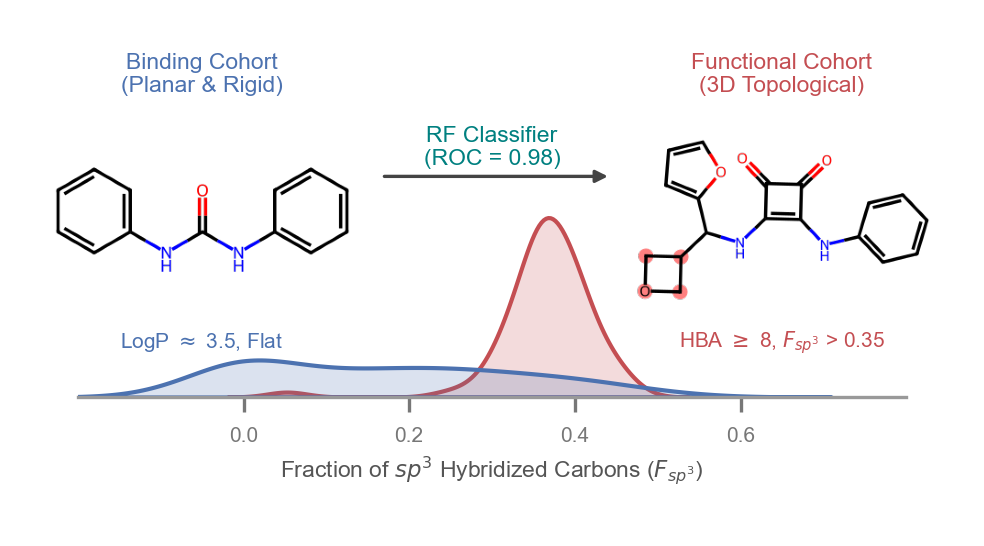

In [9]:
# ---------------------------------------------------------------------
# 8.7 TOC GRAPHIC (With Automated Archetype Verification)
# ---------------------------------------------------------------------
print("\nGenerating TOC Graphic...")

# 1. Automated Verification of Archetypes
expected_binder = 'O=C(Nc1ccccc1)Nc1ccccc1'
expected_func = 'O=c1c(Nc2ccccc2)c(NC(c2ccco2)C2COC2)c1=O'

actual_top_bind = p_bind['BM_Scaffold_SMILES'].value_counts().index[0]
actual_top_func = p_func['BM_Scaffold_SMILES'].value_counts().index[0]

print("Verifying TOC archetypes against empirical data...")
if (actual_top_bind == expected_binder) and (actual_top_func == expected_func):
    print("-> Verification Passed: Hardcoded TOC scaffolds matched the primary empirical scaffolds.")
else:
    print("-> WARNING: Top scaffolds have shifted. TOC graphic may no longer represent the statistical majority.")
    print(f"   Actual Top Binding: {actual_top_bind}")
    print(f"   Actual Top Functional: {actual_top_func}")

# 2. Generate Graphic
fig_toc, ax_toc = plt.subplots(figsize=(3.25, 1.75), dpi=300)

sns.kdeplot(data=combined, x='Fsp3', hue='Modality', ax=ax_toc, fill=True,
            palette=CUSTOM_PALETTE, alpha=0.2, linewidth=1.0, legend=True)

ax_toc.set_xlim(-0.2, 0.8)
ax_toc.set_ylim(0, 10)
ax_toc.spines['top'].set_visible(False)
ax_toc.spines['right'].set_visible(False)
ax_toc.spines['left'].set_visible(False)
ax_toc.set_yticks([])
ax_toc.set_ylabel('')

ax_toc.spines['bottom'].set_color('#999999')
ax_toc.spines['bottom'].set_linewidth(0.8)
ax_toc.set_xticks([0.0, 0.2, 0.4, 0.6])
ax_toc.tick_params(axis='x', colors='#777777', labelsize=5)
ax_toc.set_xlabel('Fraction of $sp^3$ Hybridized Carbons ($F_{sp^3}$)', fontsize=5.5, fontweight='bold', color='#555555', labelpad=2)

handles, labels = ax_toc.get_legend_handles_labels()
ax_toc.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.25),
              ncol=2, fontsize=5, frameon=False, labelcolor='#555555')

mol_func = Chem.MolFromSmiles(expected_func)
mol_binder = Chem.MolFromSmiles(expected_binder)
oxetane_match = mol_func.GetSubstructMatch(Chem.MolFromSmarts('C1COC1'))

dopts = Draw.rdMolDraw2D.MolDrawOptions()
dopts.clearBackground = False
dopts.bondLineWidth = 3.5

img_func = Draw.MolToImage(mol_func, size=(350, 350), highlightAtoms=oxetane_match, options=dopts)
img_binder = Draw.MolToImage(mol_binder, size=(350, 350), options=dopts)

ab_binder = AnnotationBbox(OffsetImage(img_binder, zoom=0.22), (-0.05, 4.8), frameon=False)
ax_toc.add_artist(ab_binder)
ax_toc.text(-0.05, 8.8, 'Binding Cohort\n(Planar & Rigid)', ha='center', va='center', fontsize=5.5, fontweight='bold', color=CUSTOM_PALETTE['Binding Cohort'])
ax_toc.text(-0.05, 1.5, r'LogP $\approx$ 3.5, Flat', ha='center', va='center', fontsize=5, fontweight='bold', color=CUSTOM_PALETTE['Binding Cohort'])

ab_func = AnnotationBbox(OffsetImage(img_func, zoom=0.22), (0.65, 4.8), frameon=False)
ax_toc.add_artist(ab_func)
ax_toc.text(0.65, 8.8, 'Functional Cohort\n(3D Topological)', ha='center', va='center', fontsize=5.5, fontweight='bold', color=CUSTOM_PALETTE['Functional Cohort'])
ax_toc.text(0.65, 1.5, r'HBA $\geq$ 8, $F_{sp^3}$ > 0.35', ha='center', va='center', fontsize=5, fontweight='bold', color=CUSTOM_PALETTE['Functional Cohort'])

arrow = FancyArrowPatch((0.16, 6.0), (0.45, 6.0), mutation_scale=6, color='#444444', linewidth=0.8, arrowstyle='-|>')
ax_toc.add_patch(arrow)
ax_toc.text(0.30, 6.8, f'RF Classifier\n(ROC = {test_roc_auc:.2f})', ha='center', va='center', fontsize=5.5, fontweight='bold', color='teal')

plt.tight_layout(pad=0.5)
fig_toc.savefig('TOC_Graphic_Fsp3_Final.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.show()
plt.close(fig_toc)